In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats
import cartopy.crs as ccrs
import cartopy.mpl.ticker as cticker
from cartopy.util import add_cyclic_point

In [2]:
ds_sst = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")
#ds_sst = ds_sst.sel(time = slice('1979', '2019')) 
ds_sst.load()

<xarray.Dataset>
Dimensions:    (lat: 89, lon: 180, time: 2030, nbnds: 2)
Coordinates:
  * lat        (lat) float32 88.0 86.0 84.0 82.0 ... -82.0 -84.0 -86.0 -88.0
  * lon        (lon) float32 0.0 2.0 4.0 6.0 8.0 ... 352.0 354.0 356.0 358.0
  * time       (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 9.969e+36 9.969e+36 ... 9.969e+36 9.969e+36
    sst        (time, lat, lon) float32 -1.8 -1.8 -1.8 -1.8 ... nan nan nan nan
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
    creator_url_original:      https://www.ncei.noaa.gov
    license:                   No constraints on data access or use
    comment:                   SSTs were observed by conventional thermometer...
    summary:                   ERSST.v5 is developed based on v4 after revisi...
    dataset_title:             NOAA Extended Reconstructed SST V5
    data_modified:             2023-03-04

In [3]:
#make anomaly
sst_clim = ds_sst.sst.groupby('time.month').mean(dim = 'time')
sst_anom = ds_sst.sst.groupby('time.month') - sst_clim

In [4]:
#detrend 移掉趨勢 
#區分出variability跟trend。
from scipy.signal import detrend
sst_anom_detrended = xr.apply_ufunc(detrend, sst_anom.fillna(0),
                                    kwargs={'axis': 0}).where(~sst_anom.isnull())

In [5]:
sst_anom_nino34 = sst_anom_detrended.sel(lat = slice(5, -5), lon = slice(190, 240)) 
sst_anom_nino34_mean = sst_anom_nino34.mean(dim = ('lon', 'lat'))
oni34 = sst_anom_nino34_mean.rolling(time = 3, center=True).mean()
#ds_oni = oni34.sel(time=slice('1979', '2019'))  

In [6]:
#ds_oni
oni34

<xarray.DataArray 'sst' (time: 2030)>
array([        nan,  0.17986898,  0.38415575, ..., -0.8184561 ,
       -0.7356249 ,         nan], dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 1854-01-01 1854-02-01 ... 2023-02-01
    month    (time) int64 1 2 3 4 5 6 7 8 9 10 11 ... 4 5 6 7 8 9 10 11 12 1 2

In [7]:
%matplotlib inline
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import sklearn.ensemble
import scipy.stats
from sklearn.model_selection import train_test_split
from tqdm import tqdm
import xarray as xr
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import sklearn
import sklearn.ensemble
import scipy.stats
from sklearn.model_selection import train_test_split 
from scipy.stats import pearsonr
from sklearn.metrics import mean_squared_error

In [8]:
#Scaffold code to load in data.  This code cell is mostly data wrangling

def load_enso_indices():
  """
  Reads in the netcdf file to output a pandas Series of ENSO vals

  outputs
  -------

    pd.Series : monthly ENSO values starting from 1870-01-01
  """
  #read SST

  ds_sst = oni34
  ds_sst
  ds_sst = ds_sst.sel(time = slice('1900', '2020'))
  ds_sst.load()
  ts_nino34 = ds_sst.to_series()
  return ts_nino34

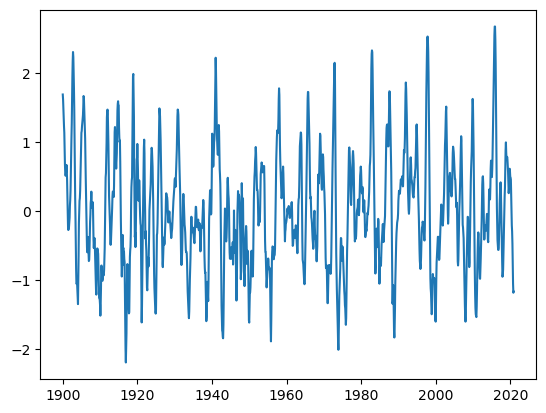

In [9]:
# This cell tests the reading of 
nino34 = load_enso_indices()
#nino34
#nino34 = nino34.to_series()
#ts_nino34 = nino34["sst"].to_series()

plt.figure()
plt.plot(nino34)

In [10]:
def assemble_basic_predictors_predictands(start_date, end_date, lead_time, 
                                    n_components=32):
  """
  inputs
  ------

      start_date        str : the start date from which to extract sst
      end_date          str : the end date 
      lead_time         str : the number of months between each sst
                              value and the target Nino3.4 Index
      n_components      int : the number of components to use for PCA

  outputs
  -------
      Returns a tuple of the predictors (np array of sst temperature anomalies) 
      and the predictands (np array the ENSO index at the specified lead time).

  """
  ds = xr.open_dataset(r"C:\Users\USER\Desktop\MA\111-2\CAD\Week6\sst.mnmean.nc")

  
  sst = ds['sst'].sel(time=slice(start_date, end_date))
  num_time_steps = sst.shape[0]
  
  #sst is a 3D array: (time_steps, lat, lon)
  #in this tutorial, we will not be using ML models that take
  #advantage of the spatial nature of global temperature
  #therefore, we reshape sst into a 2D array: (time_steps, lat*lon)
  #(At each time step, there are lat*lon predictors)
  sst = sst.values.reshape(num_time_steps, -1)
  sst[np.isnan(sst)] = 0

  X = sst

  start_date_plus_lead = pd.to_datetime(start_date) + \
                        pd.DateOffset(months=lead_time)
  end_date_plus_lead = pd.to_datetime(end_date) + \
                      pd.DateOffset(months=lead_time)
  y = load_enso_indices()[slice(start_date_plus_lead, 
                                end_date_plus_lead)]


  ds.close()
  return X, y


In [11]:
def plot_nino_time_series(y, predictions, title):
  """
  inputs
  ------
    y           pd.Series : time series of the true Nino index
    predictions np.array  : time series of the predicted Nino index (same
                            length and time as y)
    titile                : the title of the plot

  outputs
  -------
    None.  Displays the plot
  """
  predictions = pd.Series(predictions, index=y.index)
  predictions = predictions.sort_index()
  y = y.sort_index()

  plt.plot(y, label='Ground Truth')
  plt.plot(predictions, '--', label='ML Predictions')
  plt.legend(loc='best')
  plt.title(title)
  plt.ylabel('Nino3.4 Index')
  plt.xlabel('Date')
  plt.show()
  plt.close()

In [12]:
# Sample loading of train, val, and test sets
X_train, y_train = assemble_basic_predictors_predictands('1900-01-01','1930-12-31', lead_time = 1)
X_val, y_val = assemble_basic_predictors_predictands('1975-01-01','2006-12-31', lead_time = 1)
X_test, y_test = assemble_basic_predictors_predictands('2007-01-01','2020-12-31', lead_time = 1)

RMSE: 0.36


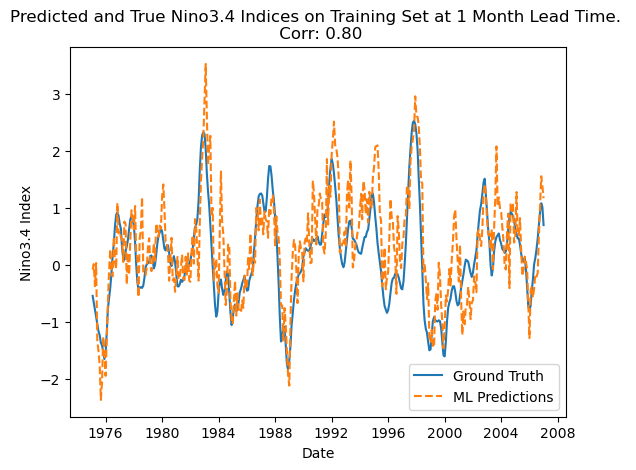

In [13]:
#Let's use a linear regression model
regr = sklearn.linear_model.LinearRegression()
regr.fit(X_train,y_train)

predictions = regr.predict(X_val)
corr, _ = scipy.stats.pearsonr(predictions, y_val)
rmse = mean_squared_error(y_val, predictions)
print("RMSE: {:.2f}".format(rmse))

plot_nino_time_series(y_val, predictions, 
    'Predicted and True Nino3.4 Indices on Training Set at 1 Month Lead Time. \n Corr: {:.2f}'.format(corr))

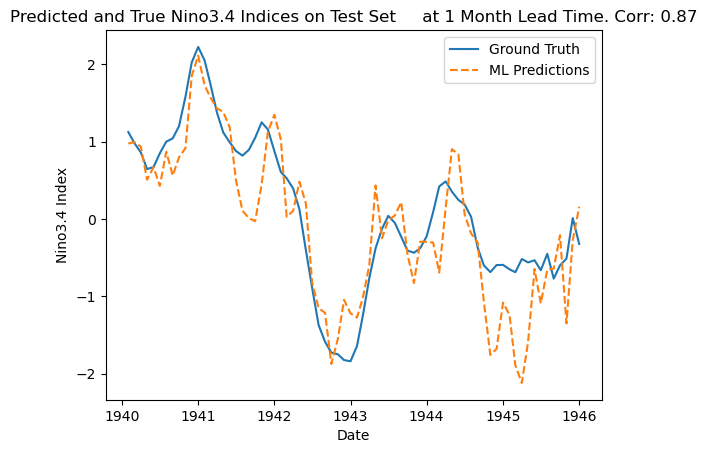

In [22]:
X_train, y_train = assemble_basic_predictors_predictands('1900-01-01','1920-12-31', 
                                                1)
X_test, y_test = assemble_basic_predictors_predictands('1940-01-01','1945-12-31', 1)
regr_1_month_lr = sklearn.linear_model.LinearRegression()
regr_1_month_lr.fit(X_train,y_train)

#First, let's plot the performance of the model
predictions_test = regr_1_month_lr.predict(X_test)
corr, _ = scipy.stats.pearsonr(predictions_test, y_test)
plot_nino_time_series(y_test, predictions_test,
    'Predicted and True Nino3.4 Indices on Test Set \
    at 1 Month Lead Time. Corr: {:.2f}'.format(corr))

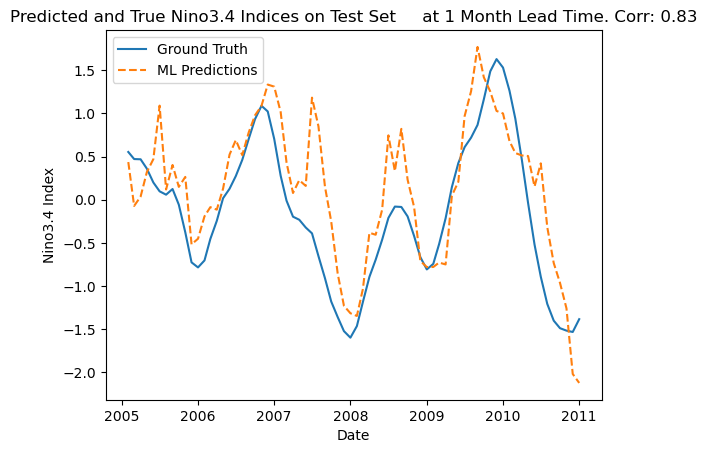

In [26]:
X_train, y_train = assemble_basic_predictors_predictands('1900-01-01','1920-12-31', 
                                                1)
X_test, y_test = assemble_basic_predictors_predictands('2005-01-01','2010-12-31', 1)
regr_1_month_lr = sklearn.linear_model.LinearRegression()
regr_1_month_lr.fit(X_train,y_train)

#First, let's plot the performance of the model
predictions_test = regr_1_month_lr.predict(X_test)
corr, _ = scipy.stats.pearsonr(predictions_test, y_test)
plot_nino_time_series(y_test, predictions_test,
    'Predicted and True Nino3.4 Indices on Test Set \
    at 1 Month Lead Time. Corr: {:.2f}'.format(corr))

#此不多加了regularization去修正overgitting這件事
#用不同時間段的資料去做training即testing，所以可以發現和上面的結果有一點不一樣

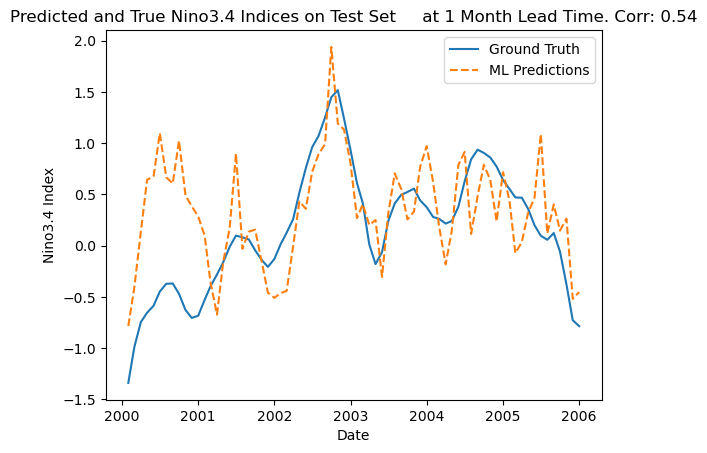

In [18]:
X_train, y_train = assemble_basic_predictors_predictands('1900-01-01','1920-12-31', 
                                                1)
X_test, y_test = assemble_basic_predictors_predictands('2000-01-01','2005-12-31', 1)
regr_1_month_lr = sklearn.linear_model.LinearRegression()
regr_1_month_lr.fit(X_train,y_train)

#First, let's plot the performance of the model
predictions_test = regr_1_month_lr.predict(X_test)
corr, _ = scipy.stats.pearsonr(predictions_test, y_test)
plot_nino_time_series(y_test, predictions_test,
    'Predicted and True Nino3.4 Indices on Test Set \
    at 1 Month Lead Time. Corr: {:.2f}'.format(corr))

#此不多加了regularization去修正overgitting這件事
#用不同時間段的資料去做training即testing，所以可以發現和上面的結果有一點不一樣